# Samurai Commit Generation Benchmark Visualization

This notebook visualizes latency and throughput graphs from benchmark CSV files.

**Metrics visualized:**
- Update Latency (time from enqueue to completion)
- Block Latency (time from submission to completion)
- Update Throughput (updates per second)
- Block Throughput (blocks per second)

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Configuration
plt.style.use('default')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

In [38]:
# === CONFIGURE THIS ===
UPDATES_FILE = "../../benchmark_output/bench_updates_20260113_020913.csv"
BLOCKS_FILE = "../../benchmark_output/bench_blocks_20260113_020913.csv"

# Time window for aggregation (seconds)
WINDOW_SECONDS = 5.0

# Warmup and cooldown periods to trim (seconds)
WARMUP_SECONDS = 0.0
COOLDOWN_SECONDS = 0.0
# ======================

## Helper Functions

In [39]:
def load_updates_csv(filepath: str) -> pd.DataFrame:
    """Load updates CSV file."""
    df = pd.read_csv(filepath)
    # Convert nanoseconds to seconds for time-based grouping
    df["completed_at_s"] = df["completed_at_ns"] / 1e9
    # Convert latency to milliseconds for readability
    df["latency_ms"] = df["latency_ns"] / 1e6
    return df


def load_blocks_csv(filepath: str) -> pd.DataFrame:
    """Load blocks CSV file."""
    df = pd.read_csv(filepath)
    # Convert nanoseconds to seconds
    df["submitted_at_s"] = df["submitted_at_ns"] / 1e9
    df["completed_at_s"] = df["completed_at_ns"] / 1e9
    # Calculate latency in milliseconds
    df["latency_ms"] = (df["completed_at_ns"] - df["submitted_at_ns"]) / 1e6
    return df


def trim_warmup_cooldown(
    df: pd.DataFrame, time_col: str, warmup_s: float, cooldown_s: float
) -> pd.DataFrame:
    """Trim warmup and cooldown periods from the data."""
    if df.empty:
        return df

    min_time = df[time_col].min()
    max_time = df[time_col].max()

    start_time = min_time + warmup_s
    end_time = max_time - cooldown_s

    if start_time >= end_time:
        print(
            f"Warning: warmup ({warmup_s}s) + cooldown ({cooldown_s}s) >= total duration. No data left."
        )
        return df.iloc[0:0]  # Return empty dataframe with same columns

    trimmed = df[(df[time_col] >= start_time) & (df[time_col] <= end_time)].copy()
    # Normalize time to start from 0
    trimmed["time_normalized"] = trimmed[time_col] - start_time
    return trimmed


def aggregate_by_window(
    df: pd.DataFrame, time_col: str, window_s: float, value_col: str, agg_func: str
) -> pd.DataFrame:
    """Aggregate data by time window."""
    if df.empty:
        return pd.DataFrame(columns=["window_start", "value"])

    # Create window bins
    df = df.copy()
    df["window"] = (df[time_col] // window_s).astype(int)

    if agg_func == "mean":
        result = df.groupby("window")[value_col].mean().reset_index()
    elif agg_func == "count":
        result = df.groupby("window").size().reset_index(name="value")
        result["value"] = result["value"] / window_s  # Convert to per-second rate
    else:
        raise ValueError(f"Unknown aggregation function: {agg_func}")

    result["window_start"] = result["window"] * window_s
    if agg_func == "mean":
        result = result.rename(columns={value_col: "value"})

    return result[["window_start", "value"]]

In [40]:
def plot_latency(ax, df, title, ylabel, color, window_s):
    """Plot latency over time."""
    if df.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        return

    agg = aggregate_by_window(df, "time_normalized", window_s, "latency_ms", "mean")

    ax.plot(agg["window_start"], agg["value"], color=color, linewidth=1.5)
    ax.fill_between(agg["window_start"], agg["value"], alpha=0.3, color=color)
    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

    # Add statistics annotation
    if not df.empty:
        mean_lat = df["latency_ms"].mean()
        p50 = df["latency_ms"].median()
        p95 = df["latency_ms"].quantile(0.95)
        p99 = df["latency_ms"].quantile(0.99)
        stats_text = f"Mean: {mean_lat:.2f}ms\nP50: {p50:.2f}ms\nP95: {p95:.2f}ms\nP99: {p99:.2f}ms"
        ax.text(
            0.98, 0.98, stats_text,
            transform=ax.transAxes,
            fontsize=9,
            verticalalignment="top",
            horizontalalignment="right",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
        )


def plot_throughput(ax, df, time_col, title, ylabel, color, window_s):
    """Plot throughput over time using line chart with fill."""
    if df.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        return

    agg = aggregate_by_window(df, "time_normalized", window_s, None, "count")

    ax.plot(agg["window_start"], agg["value"], color=color, linewidth=1.5)
    ax.fill_between(agg["window_start"], agg["value"], alpha=0.3, color=color)
    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

    # Add statistics annotation
    if not agg.empty:
        avg_throughput = agg["value"].mean()
        max_throughput = agg["value"].max()
        min_throughput = agg["value"].min()
        stats_text = f"Avg: {avg_throughput:.1f}/s\nMax: {max_throughput:.1f}/s\nMin: {min_throughput:.1f}/s"
        ax.text(
            0.98, 0.98, stats_text,
            transform=ax.transAxes,
            fontsize=9,
            verticalalignment="top",
            horizontalalignment="right",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
        )

## Load and Prepare Data

In [41]:
# Load data
print("Loading data...")
print(f"  Updates: {UPDATES_FILE}")
print(f"  Blocks:  {BLOCKS_FILE}")

updates_df = load_updates_csv(UPDATES_FILE)
blocks_df = load_blocks_csv(BLOCKS_FILE)

print(f"Loaded {len(updates_df)} update records and {len(blocks_df)} block records")

# Trim warmup and cooldown
print(f"\nTrimming warmup ({WARMUP_SECONDS}s) and cooldown ({COOLDOWN_SECONDS}s)...")
updates_trimmed = trim_warmup_cooldown(updates_df, "completed_at_s", WARMUP_SECONDS, COOLDOWN_SECONDS)
blocks_trimmed = trim_warmup_cooldown(blocks_df, "completed_at_s", WARMUP_SECONDS, COOLDOWN_SECONDS)

print(f"After trimming: {len(updates_trimmed)} updates and {len(blocks_trimmed)} blocks")

Loading data...
  Updates: ../../benchmark_output/bench_updates_20260113_020913.csv
  Blocks:  ../../benchmark_output/bench_blocks_20260113_020913.csv
Loaded 4507114 update records and 11571 block records

Trimming warmup (0.0s) and cooldown (0.0s)...
After trimming: 4507114 updates and 11571 blocks


## Combined 2x2 Plot

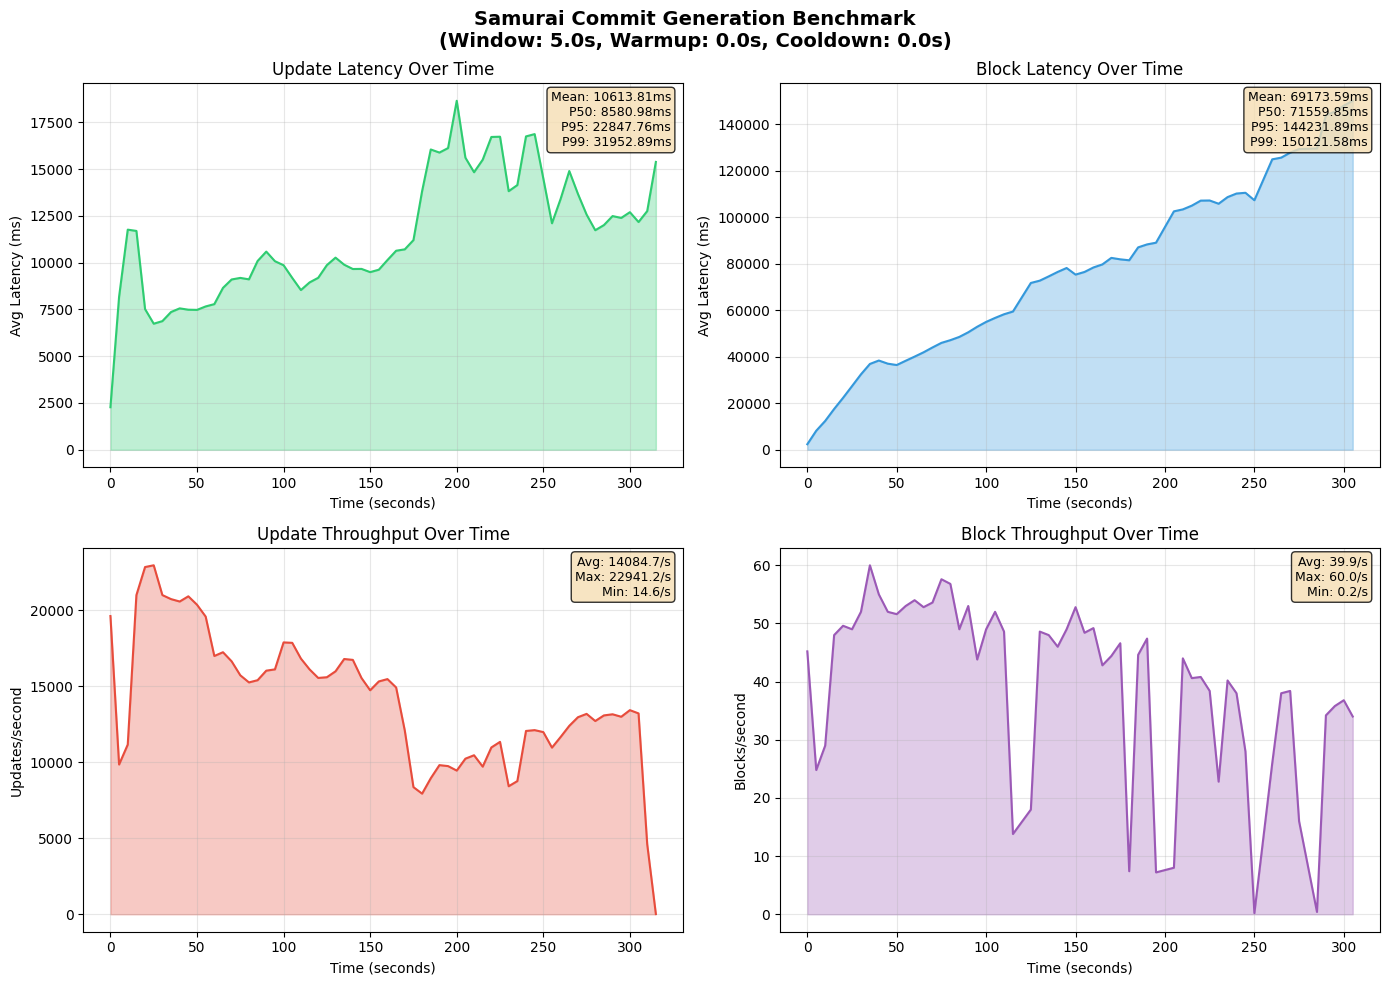

In [42]:
# Create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f"Samurai Commit Generation Benchmark\n(Window: {WINDOW_SECONDS}s, Warmup: {WARMUP_SECONDS}s, Cooldown: {COOLDOWN_SECONDS}s)",
    fontsize=14,
    fontweight="bold",
)

# Plot 1: Update Latency
plot_latency(
    axes[0, 0],
    updates_trimmed,
    "Update Latency Over Time",
    "Avg Latency (ms)",
    "#2ecc71",
    WINDOW_SECONDS,
)

# Plot 2: Block Latency
plot_latency(
    axes[0, 1],
    blocks_trimmed,
    "Block Latency Over Time",
    "Avg Latency (ms)",
    "#3498db",
    WINDOW_SECONDS,
)

# Plot 3: Update Throughput
plot_throughput(
    axes[1, 0],
    updates_trimmed,
    "time_normalized",
    "Update Throughput Over Time",
    "Updates/second",
    "#e74c3c",
    WINDOW_SECONDS,
)

# Plot 4: Block Throughput
plot_throughput(
    axes[1, 1],
    blocks_trimmed,
    "time_normalized",
    "Block Throughput Over Time",
    "Blocks/second",
    "#9b59b6",
    WINDOW_SECONDS,
)

plt.tight_layout()
plt.show()

## Individual Plots

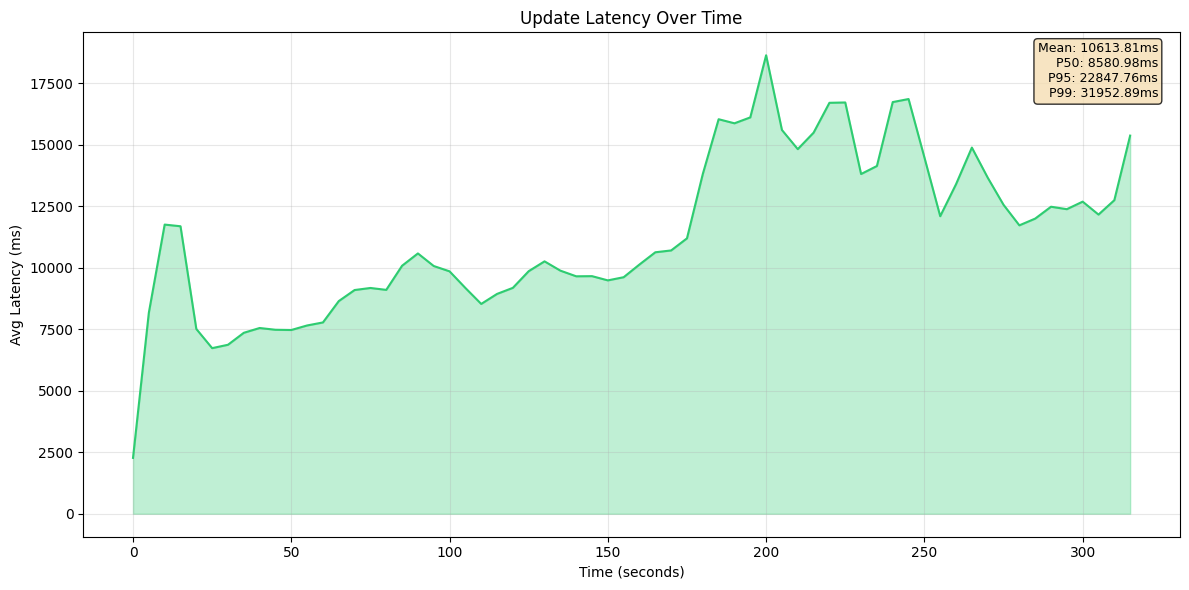

In [43]:
# Update Latency (individual plot)
fig, ax = plt.subplots(figsize=(12, 6))
plot_latency(ax, updates_trimmed, "Update Latency Over Time", "Avg Latency (ms)", "#2ecc71", WINDOW_SECONDS)
plt.tight_layout()
plt.show()

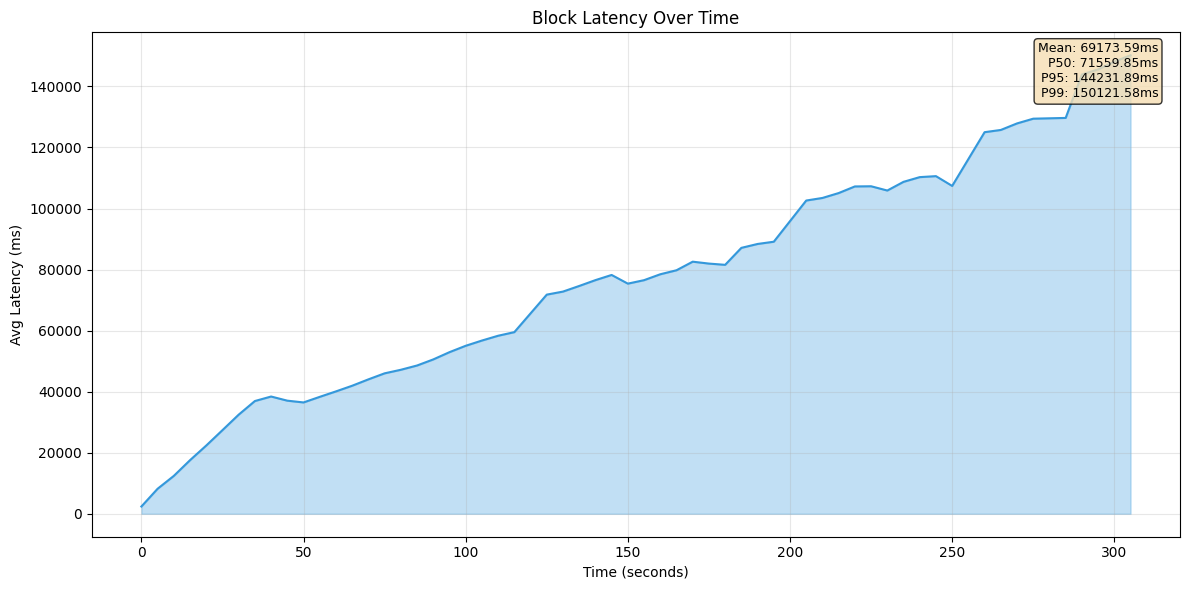

In [44]:
# Block Latency (individual plot)
fig, ax = plt.subplots(figsize=(12, 6))
plot_latency(ax, blocks_trimmed, "Block Latency Over Time", "Avg Latency (ms)", "#3498db", WINDOW_SECONDS)
plt.tight_layout()
plt.show()

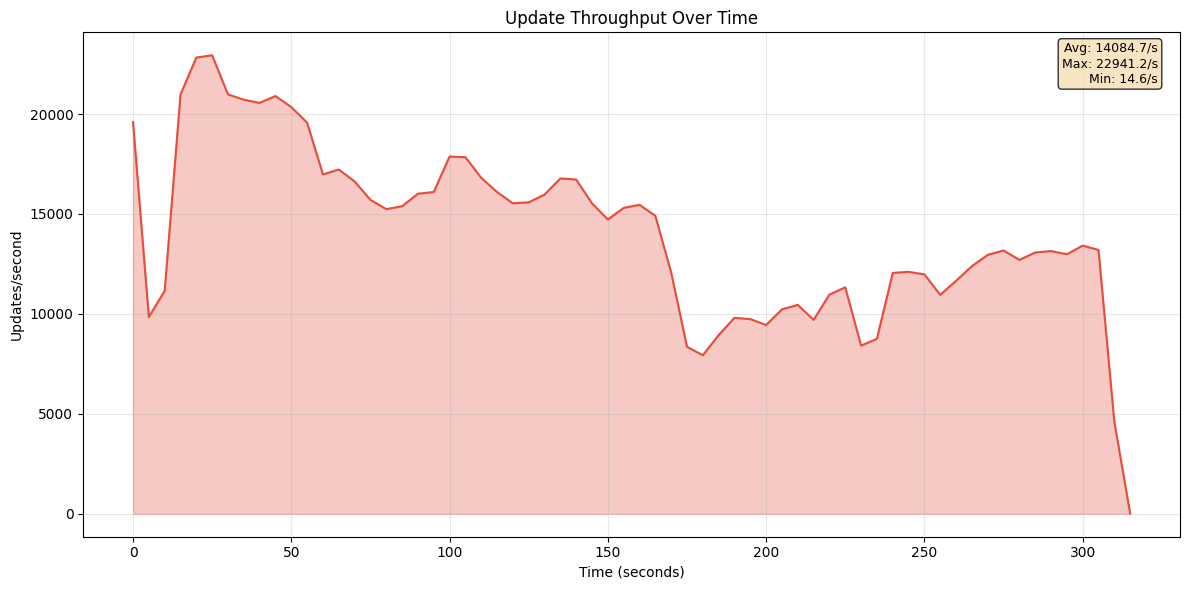

In [45]:
# Update Throughput (individual plot)
fig, ax = plt.subplots(figsize=(12, 6))
plot_throughput(ax, updates_trimmed, "time_normalized", "Update Throughput Over Time", "Updates/second", "#e74c3c", WINDOW_SECONDS)
plt.tight_layout()
plt.show()

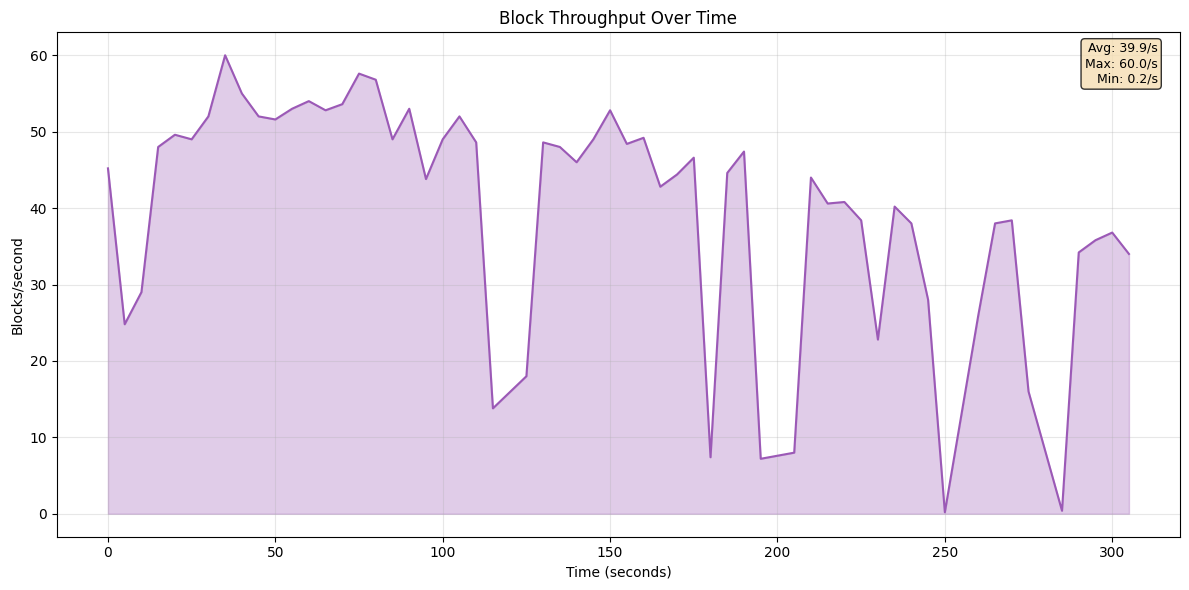

In [46]:
# Block Throughput (individual plot)
fig, ax = plt.subplots(figsize=(12, 6))
plot_throughput(ax, blocks_trimmed, "time_normalized", "Block Throughput Over Time", "Blocks/second", "#9b59b6", WINDOW_SECONDS)
plt.tight_layout()
plt.show()

## Summary Statistics

In [47]:
# Summary statistics
print("=" * 80)
print("Update Latency Statistics")
print("=" * 80)
if not updates_trimmed.empty:
    print(f"{'Count:':<20} {len(updates_trimmed):>15,}")
    print(f"{'Mean:':<20} {updates_trimmed['latency_ms'].mean():>14.2f} ms")
    print(f"{'Std Dev:':<20} {updates_trimmed['latency_ms'].std():>14.2f} ms")
    print(f"{'Min:':<20} {updates_trimmed['latency_ms'].min():>14.2f} ms")
    print(f"{'P50 (Median):':<20} {updates_trimmed['latency_ms'].median():>14.2f} ms")
    print(f"{'P95:':<20} {updates_trimmed['latency_ms'].quantile(0.95):>14.2f} ms")
    print(f"{'P99:':<20} {updates_trimmed['latency_ms'].quantile(0.99):>14.2f} ms")
    print(f"{'Max:':<20} {updates_trimmed['latency_ms'].max():>14.2f} ms")
else:
    print("No data available")

print("\n" + "=" * 80)
print("Block Latency Statistics")
print("=" * 80)
if not blocks_trimmed.empty:
    print(f"{'Count:':<20} {len(blocks_trimmed):>15,}")
    print(f"{'Mean:':<20} {blocks_trimmed['latency_ms'].mean():>14.2f} ms")
    print(f"{'Std Dev:':<20} {blocks_trimmed['latency_ms'].std():>14.2f} ms")
    print(f"{'Min:':<20} {blocks_trimmed['latency_ms'].min():>14.2f} ms")
    print(f"{'P50 (Median):':<20} {blocks_trimmed['latency_ms'].median():>14.2f} ms")
    print(f"{'P95:':<20} {blocks_trimmed['latency_ms'].quantile(0.95):>14.2f} ms")
    print(f"{'P99:':<20} {blocks_trimmed['latency_ms'].quantile(0.99):>14.2f} ms")
    print(f"{'Max:':<20} {blocks_trimmed['latency_ms'].max():>14.2f} ms")
else:
    print("No data available")

Update Latency Statistics
Count:                     4,507,114
Mean:                      10613.81 ms
Std Dev:                    5330.94 ms
Min:                           0.27 ms
P50 (Median):               8580.98 ms
P95:                       22847.76 ms
P99:                       31952.89 ms
Max:                       42299.36 ms

Block Latency Statistics
Count:                        11,571
Mean:                      69173.59 ms
Std Dev:                   36377.40 ms
Min:                          27.74 ms
P50 (Median):              71559.85 ms
P95:                      144231.89 ms
P99:                      150121.58 ms
Max:                      151287.61 ms


In [48]:
# Throughput statistics
print("=" * 80)
print("Update Throughput Statistics")
print("=" * 80)
if not updates_trimmed.empty:
    update_throughput = aggregate_by_window(updates_trimmed, "time_normalized", WINDOW_SECONDS, None, "count")
    duration_s = updates_trimmed["time_normalized"].max() - updates_trimmed["time_normalized"].min()
    overall_throughput = len(updates_trimmed) / duration_s if duration_s > 0 else 0
    print(f"{'Total Updates:':<20} {len(updates_trimmed):>15,}")
    print(f"{'Duration:':<20} {duration_s:>14.1f} s")
    print(f"{'Overall Throughput:':<20} {overall_throughput:>14.1f} /s")
    print(f"{'Avg (per window):':<20} {update_throughput['value'].mean():>14.1f} /s")
    print(f"{'Max (per window):':<20} {update_throughput['value'].max():>14.1f} /s")
    print(f"{'Min (per window):':<20} {update_throughput['value'].min():>14.1f} /s")
else:
    print("No data available")

print("\n" + "=" * 80)
print("Block Throughput Statistics")
print("=" * 80)
if not blocks_trimmed.empty:
    block_throughput = aggregate_by_window(blocks_trimmed, "time_normalized", WINDOW_SECONDS, None, "count")
    duration_s = blocks_trimmed["time_normalized"].max() - blocks_trimmed["time_normalized"].min()
    overall_throughput = len(blocks_trimmed) / duration_s if duration_s > 0 else 0
    print(f"{'Total Blocks:':<20} {len(blocks_trimmed):>15,}")
    print(f"{'Duration:':<20} {duration_s:>14.1f} s")
    print(f"{'Overall Throughput:':<20} {overall_throughput:>14.1f} /s")
    print(f"{'Avg (per window):':<20} {block_throughput['value'].mean():>14.1f} /s")
    print(f"{'Max (per window):':<20} {block_throughput['value'].max():>14.1f} /s")
    print(f"{'Min (per window):':<20} {block_throughput['value'].min():>14.1f} /s")
else:
    print("No data available")

Update Throughput Statistics


Total Updates:             4,507,114
Duration:                     315.1 s
Overall Throughput:         14302.0 /s
Avg (per window):           14084.7 /s
Max (per window):           22941.2 /s
Min (per window):              14.6 /s

Block Throughput Statistics
Total Blocks:                 11,571
Duration:                     309.6 s
Overall Throughput:            37.4 /s
Avg (per window):              39.9 /s
Max (per window):              60.0 /s
Min (per window):               0.2 /s
